EDA


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA

Initial Data Analysis on Just KT1 Dataset

In [23]:
# Load Parquet file
file_path = r"C:\Users\missm\OneDrive\Documents\Capstone_Project_Strickland\CapstoneProject_LearningPatterns\KT1_cleaned_sample.parquet"
df = pd.read_parquet(file_path)

# Quick view
df.head(10)

,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
0,2019-08-06 12:56:30.868,1,q5012,b,38000,u1
1,2019-08-06 12:57:01.062,2,q4706,c,24000,u1
2,2019-08-06 12:58:13.432,3,q4366,b,68000,u1
3,2019-08-06 12:58:59.668,4,q4829,a,42000,u1
4,2019-08-06 13:00:01.774,5,q6528,b,59000,u1
5,2019-08-06 13:01:03.370,6,q4793,a,58000,u1
6,2019-08-06 13:01:41.746,7,q6488,a,35000,u1
7,2019-08-06 13:11:41.361,8,q356,b,23000,u1
8,2019-08-06 13:12:51.393,9,q1382,c,22000,u1
9,2019-08-06 13:14:00.758,10,q830,b,25000,u1


In [24]:
### Initial Inspection

# Shape of the dataset
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

# Data types and nulls
df.info()

# Missing values
df.isnull().sum()

# Summary statistics
df.describe(include='all')


Rows: 1402362, Columns: 6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1402362 entries, 0 to 1402361
Data columns (total 6 columns):
 #   Column        Non-Null Count    Dtype         
---  ------        --------------    -----         
 0   timestamp     1402362 non-null  datetime64[ns]
 1   solving_id    1402362 non-null  int64         
 2   question_id   1402362 non-null  object        
 3   user_answer   1402269 non-null  object        
 4   elapsed_time  1402362 non-null  int64         
 5   user_id       1402362 non-null  object        
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 64.2+ MB


,timestamp,solving_id,question_id,user_answer,elapsed_time,user_id
count,1402362,1.402362e+06,1402362,1402269,1.402362e+06,1402362
unique,NaN,NaN,11859,4,NaN,5000
top,NaN,NaN,q8074,b,NaN,u102446
freq,NaN,NaN,4705,397127,NaN,26255
mean,2018-10-15 20:29:37.980044800,1.570615e+03,NaN,NaN,2.625437e+04,NaN
min,2017-04-26 08:38:28.792000,1.000000e+00,NaN,NaN,0.000000e+00,NaN
25%,2018-02-11 05:33:58.399249920,1.770000e+02,NaN,NaN,1.600000e+04,NaN
50%,2018-08-19 05:26:50.802500096,6.400000e+02,NaN,NaN,2.100000e+04,NaN
75%,2019-07-14 14:38:20.196000,1.792000e+03,NaN,NaN,3.000000e+04,NaN
max,2019-12-02 14:25:25.437000,2.054700e+04,NaN,NaN,1.790000e+06,NaN


In [25]:
print(df.columns.tolist())


['timestamp', 'solving_id', 'question_id', 'user_answer', 'elapsed_time', 'user_id']


Visual Exploration

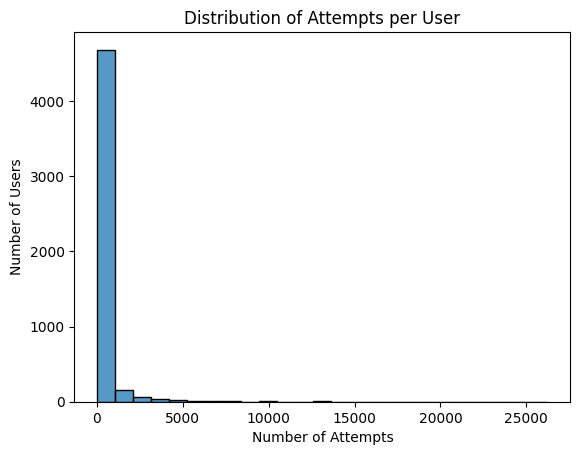

In [26]:
# Distribution of attempts per user
user_counts = df['user_id'].value_counts()
sns.histplot(user_counts, bins=25)
plt.title('Distribution of Attempts per User')
plt.xlabel('Number of Attempts')
plt.ylabel('Number of Users')
plt.show()

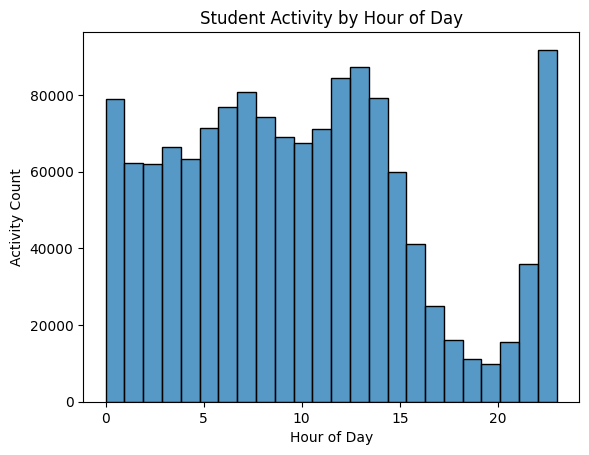

In [27]:
### Timestamp Analysis
# Convert if needed
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract hour of day
df['hour'] = df['timestamp'].dt.hour
sns.histplot(df['hour'], bins=24)
plt.title('Student Activity by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Activity Count')
plt.show()



Exploratory Data Analysis on All EdNet Datasets
[text](https://github.com/riiid/ednet)


In [28]:
# Step 1: Load Data
student_features = pd.read_parquet("student_behavior_features.parquet")
student_features = student_features.fillna(0)


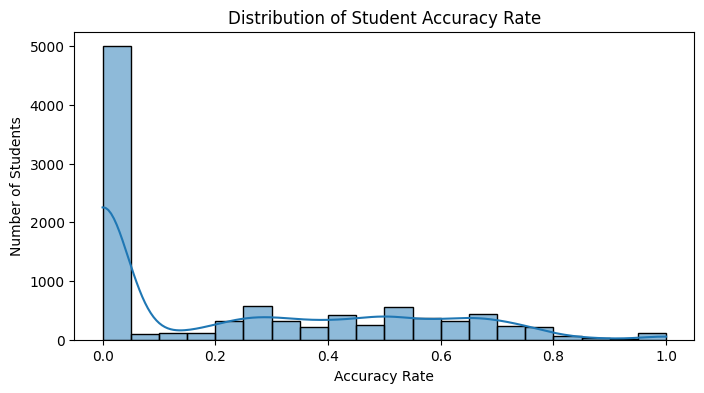

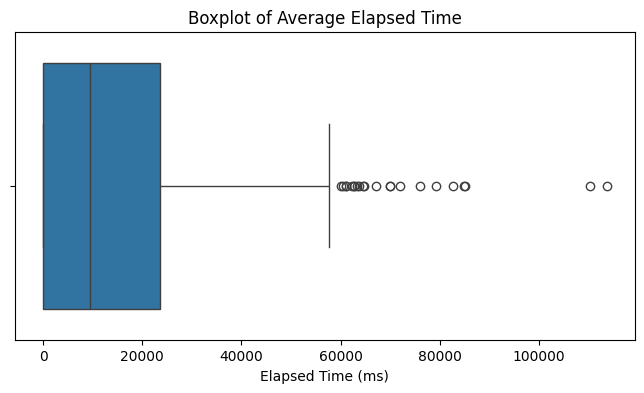

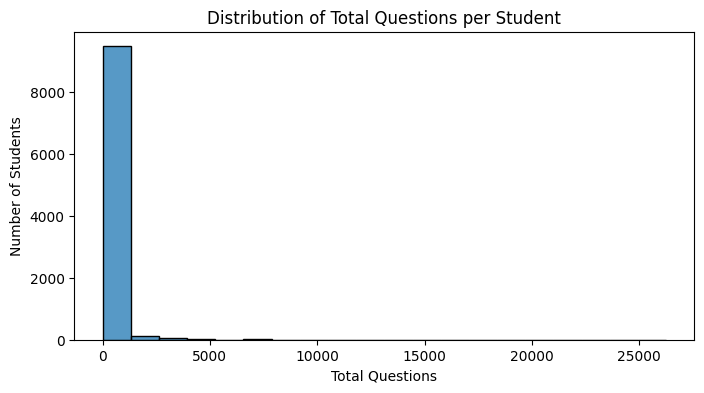

In [ ]:
# Step 2: Visualizations
plt.figure(figsize=(8, 4))
sns.histplot(student_features["accuracy_rate"], bins=20, kde=True)
plt.title("Distribution of Student Accuracy Rate")
plt.xlabel("Accuracy Rate")
plt.ylabel("Number of Students")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(x=student_features["avg_elapsed_time"])
plt.title("Boxplot of Average Elapsed Time")
plt.xlabel("Elapsed Time (ms)")
plt.show()

plt.figure(figsize=(8, 4))
sns.histplot(student_features["total_questions"], bins=20)
plt.title("Distribution of Total Questions per Student")
plt.xlabel("Total Questions")
plt.ylabel("Number of Students")
plt.show()


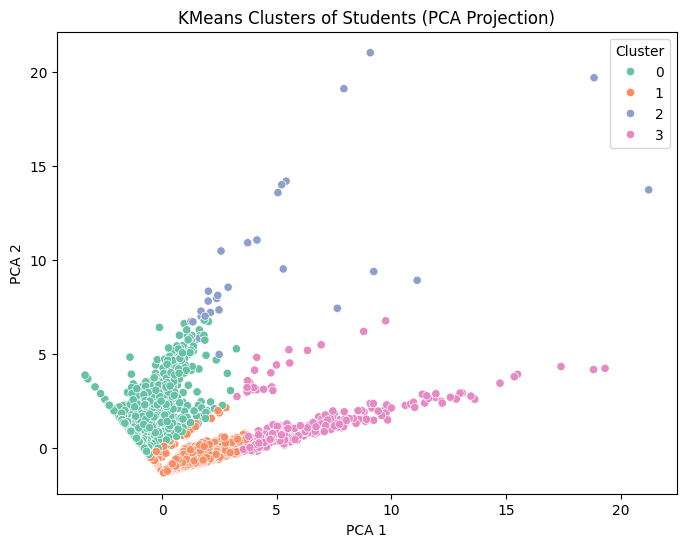


Cluster Summary:

                total_questions  avg_elapsed_time  accuracy_rate  \
kmeans_cluster                                                     
0                    221.909465      25270.810547       0.476252   
1                      4.556196        912.867615       0.008921   
2                  10315.285714      26820.498047       0.590244   
3                    275.078189       2567.475342       0.004686   

                 num_actions  active_days  
kmeans_cluster                             
0                 195.296296    59.611219  
1                3420.073487    56.252161  
2               16847.571429   375.928571  
3               54026.098765   199.534979  


In [29]:
# Step 3: Prepare Features for Clustering
features = student_features[[
    "total_questions", "avg_elapsed_time", "accuracy_rate",
    "num_responses", "num_actions", "active_days"
]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Step 4: KMeans Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
student_features["kmeans_cluster"] = kmeans.fit_predict(X_scaled)

# Step 5: DBSCAN Clustering
# dbscan = DBSCAN(eps=1.5, min_samples=5)
# student_features["dbscan_cluster"] = dbscan.fit_predict(X_scaled)

# Step 6: PCA for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
student_features["pca1"] = X_pca[:, 0]
student_features["pca2"] = X_pca[:, 1]

plt.figure(figsize=(8, 6))
sns.scatterplot(data=student_features, x="pca1", y="pca2", hue="kmeans_cluster", palette="Set2")
plt.title("KMeans Clusters of Students (PCA Projection)")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend(title="Cluster")
plt.show()

# Step 7: Interpret Cluster Characteristics
cluster_summary = student_features.groupby("kmeans_cluster")[[
    "total_questions", "avg_elapsed_time", "accuracy_rate", "num_actions", "active_days"
]].mean()

print("\nCluster Summary:\n")
print(cluster_summary)

# Optional: Save results
student_features.to_parquet("clustered_student_features.parquet")

C:\Users\missm\AppData\Local\Temp\ipykernel_13508\2985495787.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=student_features, x="kmeans_cluster", y="accuracy_rate", ci=None)


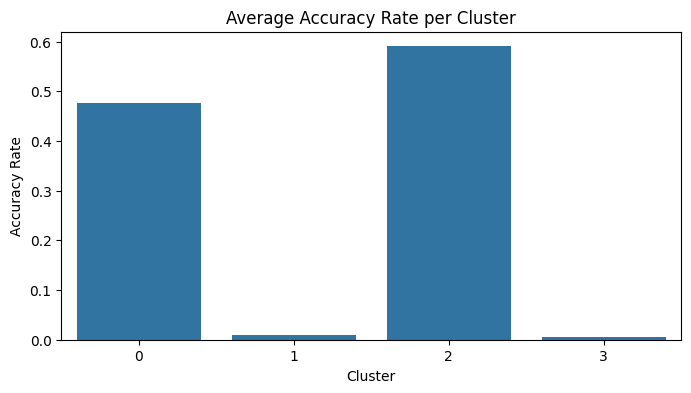

In [30]:
# 1. Average accuracy per cluster
plt.figure(figsize=(8, 4))
sns.barplot(data=student_features, x="kmeans_cluster", y="accuracy_rate", ci=None)
plt.title("Average Accuracy Rate per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Accuracy Rate")
plt.show()

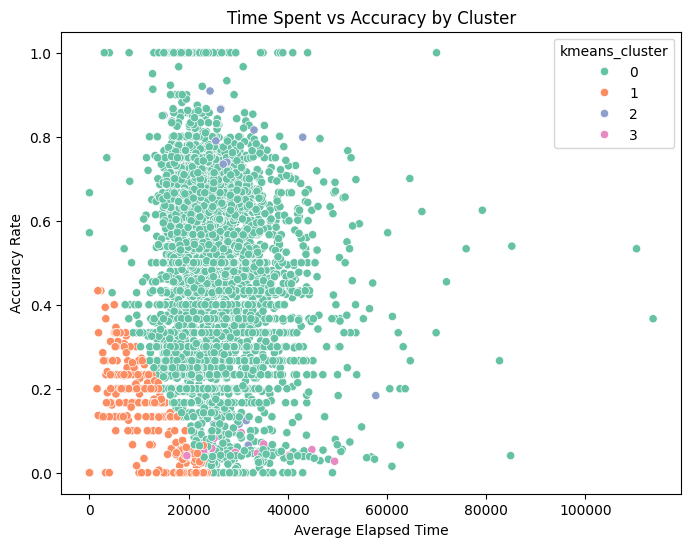

In [31]:
# 2. Time spent vs. accuracy colored by cluster
plt.figure(figsize=(8, 6))
sns.scatterplot(data=student_features, x="avg_elapsed_time", y="accuracy_rate", hue="kmeans_cluster", palette="Set2")
plt.title("Time Spent vs Accuracy by Cluster")
plt.xlabel("Average Elapsed Time")
plt.ylabel("Accuracy Rate")
plt.show()

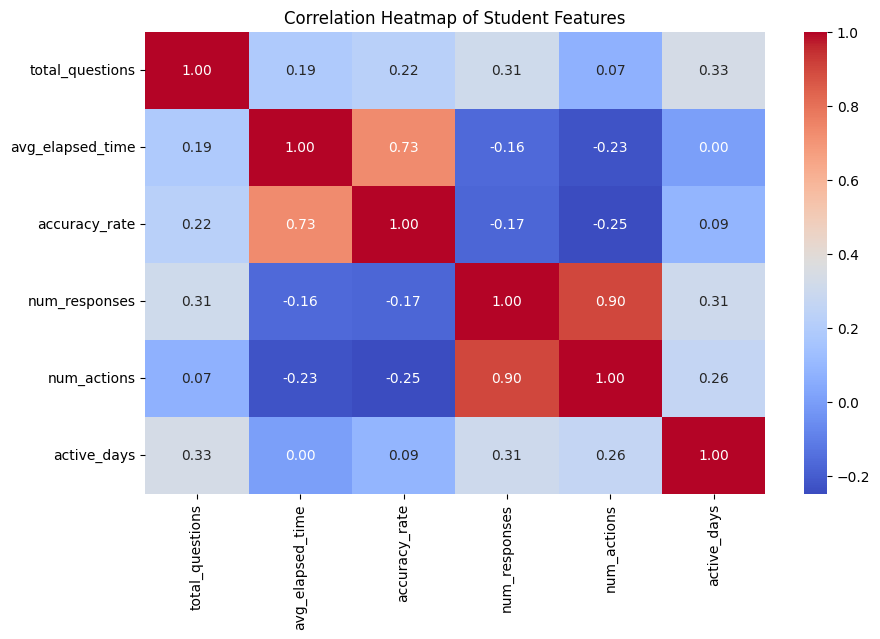

In [32]:
# 3. Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(student_features[[
    "total_questions", "avg_elapsed_time", "accuracy_rate",
    "num_responses", "num_actions", "active_days"
]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Student Features")
plt.show()

C:\Users\missm\AppData\Local\Temp\ipykernel_13508\1994099399.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="kmeans_cluster", data=student_features, palette="Set2")


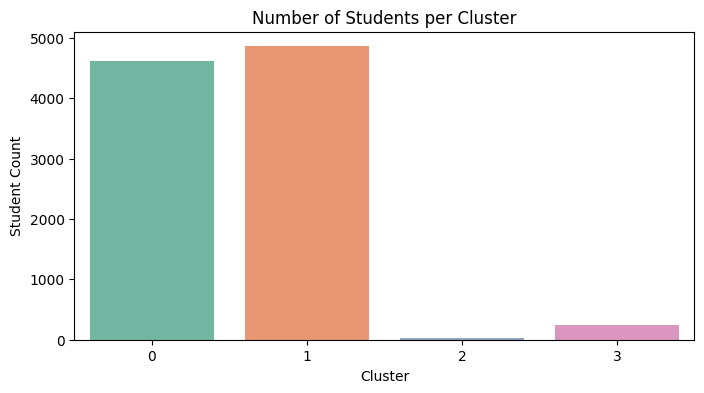

In [33]:
# 4. Distribution of students per cluster
plt.figure(figsize=(8, 4))
sns.countplot(x="kmeans_cluster", data=student_features, palette="Set2")
plt.title("Number of Students per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Student Count")
plt.show()

In [34]:
# 5. Flag struggling students
struggling_students = student_features[
    (student_features["accuracy_rate"] < 0.4) & (student_features["total_questions"] < 20)
]

print("\nStruggling Students (low accuracy and low activity):")
print(struggling_students[["accuracy_rate", "total_questions", "kmeans_cluster"]])



Struggling Students (low accuracy and low activity):
         accuracy_rate  total_questions  kmeans_cluster
user_id                                                
u10           0.310345               16               0
u100000            0.0                1               0
u100024           0.25                4               0
u100030           0.25                4               0
u100036           0.25                4               0
...                ...              ...             ...
u1834              0.0                0               1
u18340             0.0                0               1
u18341             0.0                0               1
u183419            0.0                0               1
u18342             0.0                0               1

[5267 rows x 3 columns]


In [35]:
# Save results
student_features.to_parquet("clustered_student_features.parquet")


In [38]:
path = r"C:\Users\missm\OneDrive\Documents\Capstone_Project_Strickland\CapstoneProject_LearningPatterns\clustered_student_features.parquet"
with open(path, "rb") as f:
    header = f.read(4)
    f.seek(-4, 2)
    footer = f.read(4)
print("header:", header, "footer:", footer)


header: b'PAR1' footer: b'PAR1'


In [39]:
# View parquet column titles


# Load just the metadata, not the full file
df_cluster = pd.read_parquet(r"C:\Users\missm\OneDrive\Documents\Capstone_Project_Strickland\CapstoneProject_LearningPatterns\clustered_student_features.parquet"
                     )

# Print column names
print(df_cluster.columns.tolist())


['total_questions', 'avg_elapsed_time', 'accuracy_rate', 'num_responses', 'num_actions', 'first_timestamp', 'last_timestamp', 'active_days', 'kmeans_cluster', 'pca1', 'pca2']
